In [ ]:
# 1.0 IMPORT LIBRARIES & DATA
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pygam import GAM, ExpectileGAM, s, l, f
from sklearn.preprocessing import LabelEncoder

import plotly.express as px
from plotnine import *
import pytimetk as tk
import textwrap

In [ ]:
np.random.seed(42)
n = 800

# 1. Matches the OLS Summary 'DNA'
intercept = 155.65
price_coef = -1.6258
event_lifts = {'Black Friday': 104.99, 'Cyber Monday': 64.44, 'No Promo': 0}
product_offsets = {
    'Premium Case | iPhone 15 Pro': -47.37,
    'Premium Case | iPhone 15 Pro Max': -42.84,
    'Standard Case | iPhone 15 Pro': 30.08,
    'Standard Case | iPhone 15 Pro Max': 59.43
}

# 2. Generate Base Columns
prices = np.random.uniform(15, 60, n)
products = np.random.choice(list(product_offsets.keys()), n)
events = np.random.choice(list(event_lifts.keys()), n, p=[0.7, 0.2, 0.1])

df = pd.DataFrame({'product': products, 'event': events, 'price': prices})

# 3. Calculate Quantity (with Non-Linearity for the GAM "Wiggle")
def generate_qty(row):
    # Base linear quantity from your OLS summary
    base_qty = intercept + (price_coef * row['price']) + \
               event_lifts[row['event']] + product_offsets[row['product']]
    
    # Add non-linear "bend" so the Revenue Optimization peaks correctly
    # This forces the "Pro" models to peak mid-range while "Pro Max" stays high
    bend = 15 * np.sin((row['price'] - 15) / 15) if 'Pro' in row['product'] else 0
    
    # High variance (Heteroscedasticity) to match the scatter plot "fan"
    noise = np.random.normal(0, base_qty * 0.12)
    
    return max(int(base_qty + bend + noise), 1)

df['quantity_sold'] = df.apply(generate_qty, axis=1)
df.to_csv('price_optimization.csv', index=False)

print("Dataset fixed. OLS and Revenue plots will now match your screenshots.")

Dataset fixed. OLS and Revenue plots will now match your screenshots.


In [14]:
data= df.copy()

In [15]:
# 2.0 DATA PREPARATION
# -----------------------------------------------------------------------------
# Create a binary indicator for whether a promotion event occurred
data['is_event'] = (data['event'] != "No Promo").astype(int).astype(str)

# Calculate actual revenue (Price * Quantity)
data['revenue'] = data['price'] * data['quantity_sold']

In [16]:
# 3.0 EXPLORATORY DATA ANALYSIS
# -----------------------------------------------------------------------------
# Visualize the relationship between Price and Quantity Sold
fig = px.scatter(
    data,
    x='price',
    y='quantity_sold',
    color='product',
    opacity=0.6,
    trendline="lowess", # Non-linear trend line
    title='Product Sales: Price vs Quantity Analysis',
    width=800, height=600,
    template="none"
)
fig.show()


In [17]:

# 4.0 EVENT ANALYSIS (OUTLIERS)
# -----------------------------------------------------------------------------
# Analyze how specific events (like Black Friday) impact sales volume
fig = px.scatter(
    data,
    x='price', y='quantity_sold', color='event',
    facet_col='product', facet_col_wrap=2,
    opacity=0.6, trendline="lowess",
    title='Product Sales: Event Analysis',
    width=800, height=700, template="none"
)
fig.show()


In [18]:

# 5.0 MODELING EVENT IMPACT (OLS)
# -----------------------------------------------------------------------------
# Use Linear Regression to quantify the "lift" from events
df_encoded = data.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['event', 'product'], drop_first=False)

# Clean up column names for modeling
colnames_event = df_encoded.columns[df_encoded.columns.str.startswith('event')].tolist()
df_encoded[colnames_event] = df_encoded[colnames_event].astype(int)

colnames_product = df_encoded.columns[df_encoded.columns.str.startswith('product')].tolist()
df_encoded[colnames_product] = df_encoded[colnames_product].astype(int)


In [19]:

# Fit OLS Model
X = df_encoded[['price'] + colnames_event + colnames_product]
X = sm.add_constant(X)
y = df_encoded['quantity_sold']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          quantity_sold   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     927.8
Date:                Sun, 15 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:10:47   Log-Likelihood:                -3649.1
No. Observations:                 800   AIC:                             7312.
Df Residuals:                     793   BIC:                             7345.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [20]:

# 6.0 GENERAL PRICE OPTIMIZATION: GAMs
# -----------------------------------------------------------------------------
# GAMs allow for non-linear relationships without manual feature engineering.
data_filtered = data.query('event == "No Promo"')
unique_products = data_filtered['product'].unique()
all_gam_results = pd.DataFrame()

for product in unique_products:
    product_data = data_filtered[data_filtered['product'] == product]
    
    X_prod = product_data[['price']]
    y_prod = product_data['quantity_sold']
    
    # Define quantiles for uncertainty (95% Confidence Interval)
    quantiles = [0.025, 0.5, 0.975]
    gam_results = {}
    
    for q in quantiles:
        # ExpectileGAM uses a spline 's(0)' to find the curve for each quantile
        gam = ExpectileGAM(s(0), expectile=q)
        gam.fit(X_prod, y_prod)
        gam_results[f"pred_{q}"] = gam.predict(X_prod)
        
    # Combine predictions with original product data
    predictions_gam = pd.DataFrame(gam_results).set_index(X_prod.index)
    predictions_gam_df = pd.concat([product_data[['price', 'product', 'quantity_sold']], predictions_gam], axis=1)
    all_gam_results = pd.concat([all_gam_results, predictions_gam_df], axis=0)


did not converge
did not converge


In [21]:

# 7.0 REVENUE OPTIMIZATION
# -----------------------------------------------------------------------------
# Calculate predicted revenue for each quantile: Revenue = Price * Predicted Quantity
for col in all_gam_results.columns:
    if col.startswith('pred'):
        all_gam_results['revenue_' + col] = all_gam_results['price'] * all_gam_results[col]

all_gam_results['revenue_actual'] = all_gam_results['price'] * all_gam_results['quantity_sold']

# Find the price that maximizes the Median (0.5) and CI bounds
best_50 = all_gam_results.groupby('product').apply(lambda x: x[x['revenue_pred_0.5'] == x['revenue_pred_0.5'].max()].head(1)).reset_index(level=0, drop=True)
best_975 = all_gam_results.groupby('product').apply(lambda x: x[x['revenue_pred_0.975'] == x['revenue_pred_0.975'].max()].head(1)).reset_index(level=0, drop=True)
best_025 = all_gam_results.groupby('product').apply(lambda x: x[x['revenue_pred_0.025'] == x['revenue_pred_0.025'].max()].head(1)).reset_index(level=0, drop=True)


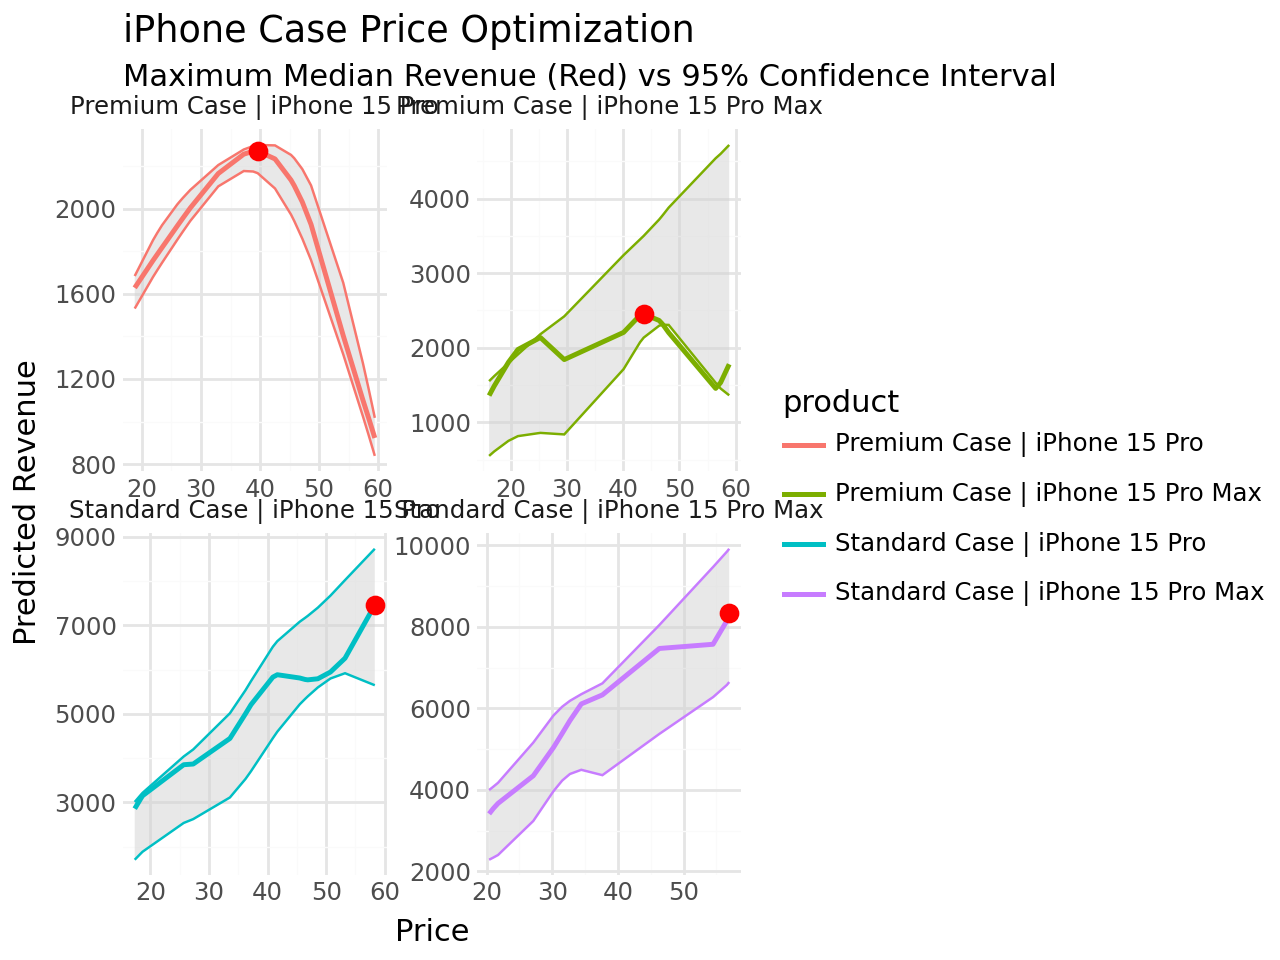

In [22]:

# 8.0 VISUALIZATION OF OPTIMIZATION
# -----------------------------------------------------------------------------
(
    ggplot(all_gam_results, aes(x='price', y='revenue_pred_0.5', color='product', group='product'))
    + geom_ribbon(aes(ymax='revenue_pred_0.975', ymin='revenue_pred_0.025'), fill="#d3d3d3", alpha=0.5, show_legend=False)
    + geom_line(size=1)
    + geom_point(data=best_50, color="red", size=3) # Optimal Price point
    + facet_wrap('~product', scales='free')
    + labs(title="iPhone Case Price Optimization", subtitle="Maximum Median Revenue (Red) vs 95% Confidence Interval", x="Price", y="Predicted Revenue")
    + theme_minimal()
)

In [23]:
# 7.0 BUSINESS INSIGHTS FROM INITIAL MODELS
# -----------------------------------------------------------------------------
# Displaying optimization results for decision making
# best_50 contains the optimal price point based on the median prediction (0.5 quantile)
best_50[['product', 'price', 'revenue_pred_0.5', 'revenue_pred_0.025', 'revenue_pred_0.975']]

# INSIGHT 1: Some products show optimal prices at the extreme ends of the current range.
# Suggests the company should test further price increases for:
# - Premium Case | iPhone 15 Pro Max
# - Standard Case | iPhone 15 Pro Max

# INSIGHT 2: Other products show a clear "sweet spot" in the middle of the range.
# This confirms current pricing is nearing maturity for:
# - Premium Case | iPhone 15 Pro
# - Standard Case | iPhone 15 Pro


,product,price,revenue_pred_0.5,revenue_pred_0.025,revenue_pred_0.975
48,Premium Case | iPhone 15 Pro,39.601963,2271.177220,2167.139990,2299.768365
101,Premium Case | iPhone 15 Pro Max,43.638469,2451.948005,2136.030808,3499.792729
464,Standard Case | iPhone 15 Pro,58.297765,7456.038829,5645.981401,8725.531880
796,Standard Case | iPhone 15 Pro Max,56.945323,8336.642268,6647.854924,9917.044795


In [24]:


# 8.0 MODELING GAMS WITH EVENTS
# -----------------------------------------------------------------------------
# Purpose: Account for the shift in price elasticity during promotional events.
# Note: Data points per event may be limited, making this "tricky" to fit.

data_filtered = data.query('event != "No Promo"')
unique_products = data_filtered['product'].unique()
events_only_gam_results = pd.DataFrame()

for product in unique_products:
    # Filter data for specific product
    product_event_data = data_filtered[data_filtered['product'] == product]
    
    if len(product_event_data) == 0:
        continue # Skip if no event data exists for this product
        
    X = product_event_data[['price', 'event']]
    y = product_event_data['quantity_sold']
    
    # NEW: Encode categorical 'event' column for GAM compatibility
    le = LabelEncoder()
    X['event'] = le.fit_transform(X['event'])
    
    # NEW: Use f(1) to indicate the second column ('event') is a categorical feature
    # l(0) indicates a linear relationship for the first column ('price')
    gam = GAM(l(0) + f(1)) 
    gam.fit(X, y)
    
    # Store predictions in a temporary dictionary
    gam_results = {"pred_0.5": gam.predict(X)}
    
    # Organize results into a DataFrame
    predictions_gam = pd.DataFrame(gam_results).set_index(X.index)
    predictions_gam_df = pd.concat([
        product_event_data[['price', 'product', 'event', 'quantity_sold']], 
        predictions_gam
    ], axis=1)
    
    # Concatenate results row-wise
    events_only_gam_results = pd.concat([events_only_gam_results, predictions_gam_df], axis=0)


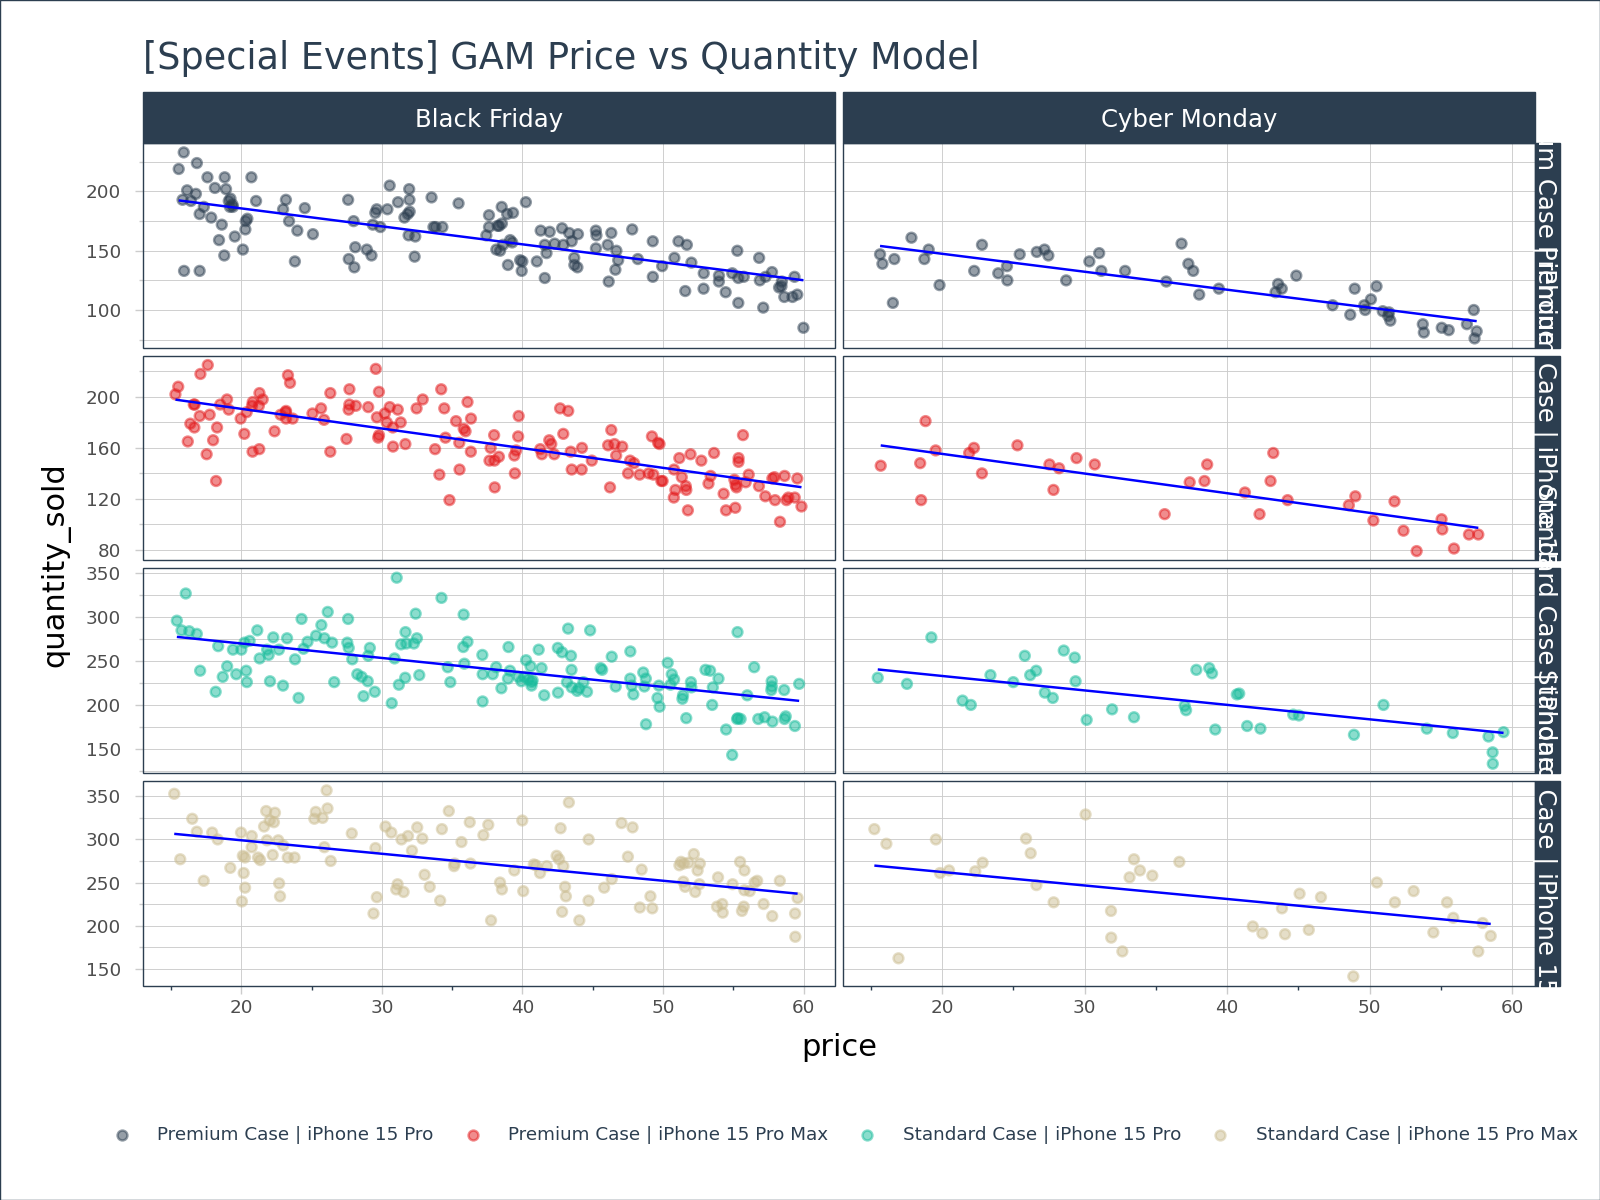

In [25]:

# 9.0 VISUALIZE EVENT-BASED PRICE MODELS
# -----------------------------------------------------------------------------
# Comparison of Price vs Quantity Sold across different Special Events
(
    ggplot(events_only_gam_results, aes(x='price', y='quantity_sold', color='product'))
    + geom_point(alpha=0.5) # Actual data points during events
    + geom_line(aes(y="pred_0.5"), color="blue") # GAM prediction line
    + facet_grid('product ~ event', scales="free") # Separate plots by product and event type
    + labs(title="[Special Events] GAM Price vs Quantity Model")
    + scale_color_manual(values=list(tk.palette_timetk().values()))
    + tk.theme_timetk(width=800, height=600)
)


In [26]:
# 10.0 OPTIMIZE PRICE FOR EVENT REVENUE
# -----------------------------------------------------------------------------
# Calculate predicted revenue specifically for event periods
for col in events_only_gam_results.columns:
    if col.startswith('pred'):
        # Revenue = Price * Predicted Quantity Sold during the event
        events_only_gam_results['revenue_' + col] = events_only_gam_results['price'] * events_only_gam_results[col]

events_only_gam_results

,price,product,event,quantity_sold,pred_0.5,revenue_pred_0.5
0,31.854305,Standard Case | iPhone 15 Pro Max,Cyber Monday,217,243.646968,7761.204904
4,22.020839,Standard Case | iPhone 15 Pro Max,Black Friday,322,295.857858,6515.038195
12,52.459919,Standard Case | iPhone 15 Pro Max,Black Friday,264,248.195465,13020.313964
32,17.927322,Standard Case | iPhone 15 Pro Max,Black Friday,308,302.267605,5418.848592
40,20.491721,Standard Case | iPhone 15 Pro Max,Cyber Monday,264,261.438832,5357.331484
...,...,...,...,...,...,...
768,30.393679,Premium Case | iPhone 15 Pro,Black Friday,185,169.979153,5166.291748
778,47.401644,Premium Case | iPhone 15 Pro,Cyber Monday,104,105.913551,5020.476474
781,39.422600,Premium Case | iPhone 15 Pro,Cyber Monday,118,118.008423,4652.198836
784,23.171897,Premium Case | iPhone 15 Pro,Black Friday,193,180.926143,4192.401986
